#### Usage: 

1. To run the BO-DBA attck:
   In order to check the efficiency of the BO-DBA attac with different models, please use any    of these model names -> perlin, gabor, BICU, BILI, CLUSTER, NN, in place of the blank        space given in this (noiseGenerator = '       ') in cell number 5.
   
2. To run the HJSA attack:
   In order to check the efficiency of the BO-DBA attac with different models, please use any    of these model names -> norm,l2,linf,in place of the blank space given in this (constraint    = '    ') in cell number 6.


In [1]:
from warnings import simplefilter 
simplefilter(action='ignore', category=FutureWarning)
import random
# according to keras docs keras.preprocessing API was deprecated
# from  keras.preprocessing.image import save_img
from tensorflow.keras.utils import save_img
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
import io
import os
import yaml
from python_files.Util import *
from IPython import display
import copy
%matplotlib inline

In [2]:
import tensorflow as tf

physical_devices = tf.config.experimental.list_physical_devices("GPU")

if physical_devices:
    for gpu in physical_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"TensorFlow detected {len(physical_devices)} GPU(s).", flush=True)
else:
    print("No GPUs detected. Sorry buddy, it's CPUs for you.", flush=True)

No GPUs detected. Sorry buddy, it's CPUs for you.


In [3]:
#Global configuration
attackMode = 'Raw' #Raw: means without defense, Detection: With adversarial exmaples detection, Target means targeted attack
queryBudgets = 2 #Query Budgets
random.seed(42) #Set random seeds

1/1 [==============================] - 0s 247ms/step
crib: 0.81951374
mosquito_net: 0.022630412
quilt: 0.012116133
studio_couch: 0.0063476334
space_heater: 0.0056863045
window_shade: 0.00494774


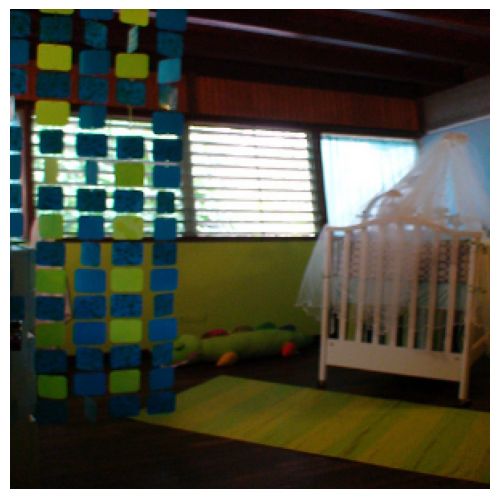

In [4]:
#Select random target image
oriImg= randomimg(mode = attackMode,target=39)
display_images(oriImg.img)

In [5]:
#BO-DBA attack
from python_files.BODBA import bayesian_attack
noiseGenerator = 'NN'#Options: perlin; gabor; BICU; BILI; CLUSTER; NN
constraint = 'linf'#norm: l2; linf
oriImg_copy = copy.deepcopy(oriImg)
with tf.device('/GPU:0'): 
       timehistory, adversarial, emissions, execution_time = bayesian_attack(oriImg_copy, max_query=queryBudgets,
                                                                       noise='BICU', constraint=constraint, init_query=1)
print(f"Carbon emissions: {emissions} kg CO2")
print(f"Execution time: {execution_time} seconds")
print(adversarial.shape)
print('Attack result: L2:{0}, Linf:{1}'.format(oriImg_copy.maxl2,oriImg_copy.maxlinf))
History=[oriImg_copy.historyl2,oriImg_copy.historylinf,timehistory]
        
DemoVisulization(oriImg_copy.img,adversarial,History,queryBudgets)
import pandas as pd
import datetime

results = pd.read_csv('GreenAttack_RawResults.csv')

new_row = {
    'date': datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
    'phase': 'Phase 1',
    'noise_type': 'BICU',
    'acquisition_function': 'EI',
    'query_budget': queryBudgets,
    'image_id': 'test_image_001',
    'run_number': 1,
    'attack_success': True,
    'queries_used': len(timehistory),
    'emissions_kg': emissions,
    'execution_time_seconds': execution_time,
    'notes': 'First fully tracked experiment'
}

results = pd.concat([results, pd.DataFrame([new_row])], ignore_index=True)
results.to_csv('GreenAttack_RawResults.csv', index=False)
print(f"Result logged to GreenAttack_RawResults.csv successfully")

ModuleNotFoundError: No module named 'codecarbon'

In [ ]:
#HJSA attack
from python_files.HJSA import hsja
constraint = 'linf'#norm: l2; linf
oriImg_copy = copy.deepcopy(oriImg)
with tf.device('/GPU:0'): 
        timehistory,adversarial = hsja(oriImg_copy,constraint=constraint,
                                                  max_query=queryBudgets,verbose=False)
if adversarial is None:
    print('Initialisation failed')
else:
    print('Attack result: L2:{0}, Linf:{1}'.format(oriImg_copy.maxl2,oriImg_copy.maxlinf))
    History=[oriImg_copy.historyl2,oriImg_copy.historylinf,timehistory]
    DemoVisulization(oriImg_copy.img,adversarial,History,queryBudgets)

In [ ]:
#RayS attack
from python_files.RayS import RayS
oriImg_copy = copy.deepcopy(oriImg)
attack = RayS(oriImg_copy,order=np.inf, epsilon=0.3, early_stopping=False)
with tf.device('/GPU:0'):
    timehistory,adversarial=attack.attack_hard_label(query_limit=queryBudgets)
print('Attack result: L2:{0}, Linf:{1}'.format(oriImg_copy.maxl2,oriImg_copy.maxlinf))
History=[oriImg_copy.historyl2,oriImg_copy.historylinf,timehistory]
        
DemoVisulization(oriImg_copy.img,adversarial,History,queryBudgets)

In [ ]:
#SignOPT attack
from python_files.SignOPT import OPT_attack_sign_SGD
oriImg_copy = copy.deepcopy(oriImg)
attack = OPT_attack_sign_SGD(oriImg_copy)
with tf.device('/GPU:0'):
    timehistory,adversarial=attack.attack_untargeted(query_limit=queryBudgets)
print('Attack result: L2:{0}, Linf:{1}'.format(oriImg_copy.maxl2,oriImg_copy.maxlinf))
History=[oriImg_copy.historyl2,oriImg_copy.historylinf,timehistory]
        
DemoVisulization(oriImg_copy.img,adversarial,History,queryBudgets)

In [ ]:
!pip install codecarbon

In [ ]:
from codecarbon import EmissionsTracker
import time

tracker = EmissionsTracker(log_level='error')
tracker.start()

time.sleep(3)

emissions = tracker.stop()
print(f"CodeCarbon is working. Test emissions: {emissions} kg CO2")

In [ ]:
import os
print("Current directory:", os.getcwd())
print("\nFiles and folders here:")
for item in os.listdir('.'):
    print(item)

In [ ]:
import os
print("Contents of python_files folder:")
for item in os.listdir('python_files'):
    print(item)

In [ ]:
import shutil
shutil.copy('python_files/BODBA.py', 'python_files/BODBA_backup.py')
print("Backup created successfully")

In [ ]:
from python_files.BODBA import bayesian_attack
print("BODBA imported successfully with CodeCarbon integration")

In [ ]:
with open('python_files/BODBA.py', 'r') as f:
    content = f.read()
    
if 'emissions = tracker.stop()' in content:
    print("CodeCarbon integration found. Changes saved correctly.")
else:
    print("CodeCarbon integration NOT found. Changes were not saved.")
    
if 'from codecarbon import EmissionsTracker' in content:
    print("EmissionsTracker import found correctly.")
else:
    print("EmissionsTracker import NOT found.")

In [ ]:
import importlib
import python_files.BODBA as BODBA_module
importlib.reload(BODBA_module)
from python_files.BODBA import bayesian_attack
print("BODBA reloaded successfully with latest changes")

In [ ]:
import inspect
from python_files.Util import randomimg
print(inspect.getsource(randomimg))

In [ ]:
import os
import random
import pandas as pd

# Set seed for reproducibility
random.seed(42)

# Get all available classes
all_classes = sorted(os.listdir(data_path))
all_classes = [c for c in all_classes if os.path.isdir(os.path.join(data_path, c))]

# Select 10 classes
selected_classes = random.sample(all_classes, 10)

# Select 10 images from each class = 100 total
image_list = []
for cls in selected_classes:
    cls_path = os.path.join(data_path, cls)
    cls_images = os.listdir(cls_path)
    selected_imgs = random.sample(cls_images, 10)
    for img in selected_imgs:
        image_list.append({
            'class': cls,
            'filename': img,
            'full_path': os.path.join(data_path, cls, img)
        })

# Save to CSV
image_df = pd.DataFrame(image_list)
image_df.to_csv('GreenAttack_ImageList.csv', index=False)
print(f"Selected {len(image_list)} images across {len(selected_classes)} classes")
print(f"Classes selected: {selected_classes}")
print(image_df.head(10))

In [ ]:
import pandas as pd

# Load your image list
image_df = pd.read_csv('GreenAttack_ImageList.csv')

# Pick the first image from your list
test_image_path = image_df.iloc[0]['full_path']
test_image_class = image_df.iloc[0]['class']
test_image_filename = image_df.iloc[0]['filename']

print(f"Loading image: {test_image_filename}")
print(f"Class: {test_image_class}")
print(f"Path: {test_image_path}")

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

image_df = pd.read_csv('GreenAttack_ImageList.csv')

# Show first image from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    # Get first image from each class (index 0, 10, 20, 30...)
    img_path = image_df.iloc[i * 10]['full_path']
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(image_df.iloc[i * 10]['class'], fontsize=8)
    axes[i].axis('off')

plt.suptitle('One Image From Each of Your 10 Categories')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
results = pd.read_csv('GreenAttack_RawResults.csv')
print(f"Total experiments logged: {len(results)}")

In [7]:
import pandas as pd
import datetime
import copy
from python_files.BODBA import bayesian_attack

# Phase 1 Settings
QUERY_BUDGET = 10
ACQUISITION = 'EI'
RUNS_PER_CONFIG = 10
NOISE_TYPES = ['perlin', 'gabor', 'BICU', 'BILI', 'NN', 'CLUSTER']

# Load image list
image_df = pd.read_csv('GreenAttack_ImageList.csv')

print("=== PHASE 1 SETUP CONFIRMED ===")
print(f"Noise types to test: {NOISE_TYPES}")
print(f"Total images: {len(image_df)}")
print(f"Runs per configuration: {RUNS_PER_CONFIG}")
print(f"Query budget: {QUERY_BUDGET}")
print(f"Acquisition function: {ACQUISITION}")
print(f"Total experiments: {len(NOISE_TYPES) * len(image_df) * RUNS_PER_CONFIG}")
print("================================")

ModuleNotFoundError: No module named 'codecarbon'

In [8]:
!pip install codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.1 MB/s  0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.9.0
    Uninstalling typing_extensions-4.9.0:
      Successfully uninstalled typing_extensions-4.9.0━━━━━━━━━━━━  2/19 [typing-extensions]
  Attempting uninstall: click━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/19 [typing-extensions]
    Found existing installation: click 7.1.2━━━━━━━━━━━━━━━━━━  2/19 [typing-extensions]
    Uninstalling click-7.1.2:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/19 [typing-extensions]
      Successfully uninstalled click-7.1.2━━━━━━━━━━━━━━━━━━━━  2/19 [typing-extensions]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19/19 [codecarbon]9 [authlib]]ions]


In [9]:
import pandas as pd
import datetime
import copy
from python_files.BODBA import bayesian_attack

# Phase 1 Settings
QUERY_BUDGET = 10
ACQUISITION = 'EI'
RUNS_PER_CONFIG = 10
NOISE_TYPES = ['perlin', 'gabor', 'BICU', 'BILI', 'NN', 'CLUSTER']

# Load image list
image_df = pd.read_csv('GreenAttack_ImageList.csv')

print("=== PHASE 1 SETUP CONFIRMED ===")
print(f"Noise types to test: {NOISE_TYPES}")
print(f"Total images: {len(image_df)}")
print(f"Runs per configuration: {RUNS_PER_CONFIG}")
print(f"Query budget: {QUERY_BUDGET}")
print(f"Acquisition function: {ACQUISITION}")
print(f"Total experiments: {len(NOISE_TYPES) * len(image_df) * RUNS_PER_CONFIG}")
print("================================")

=== PHASE 1 SETUP CONFIRMED ===
Noise types to test: ['perlin', 'gabor', 'BICU', 'BILI', 'NN', 'CLUSTER']
Total images: 100
Runs per configuration: 10
Query budget: 10
Acquisition function: EI
Total experiments: 6000


In [11]:
constraint = 'linf'
attackMode = 'Raw'
print(f"Constraint set to: {constraint}")
print(f"Attack mode set to: {attackMode}")

Constraint set to: linf
Attack mode set to: Raw


In [14]:
import os
import glob

bak_files = glob.glob('/workspace/*.bak')
bak_files += glob.glob('/workspace/emissions*.csv*')

for f in bak_files:
    os.remove(f)
    
print(f"Cleaned up {len(bak_files)} unnecessary files")

Cleaned up 1 unnecessary files


In [15]:
import pandas as pd
results = pd.read_csv('GreenAttack_RawResults.csv')
print(f"Experiments saved in your results file: {len(results)}")
print(results.tail(5))

Experiments saved in your results file: 140
                 date    phase  ... execution_time_seconds                  notes
135  2026-07-17 14:53  Phase 1  ...               3.772788  Phase 1 automated run
136  2026-07-17 14:53  Phase 1  ...               3.891376  Phase 1 automated run
137  2026-07-17 14:53  Phase 1  ...               4.407219  Phase 1 automated run
138  2026-07-17 14:53  Phase 1  ...               3.563165  Phase 1 automated run
139  2026-07-17 14:53  Phase 1  ...               3.736774  Phase 1 automated run

[5 rows x 12 columns]


In [ ]:
import pandas as pd
import datetime
import copy

# Reload existing results
existing_results = pd.read_csv('GreenAttack_RawResults.csv')
print(f"Starting with {len(existing_results)} existing experiments")

# Phase 1 settings
QUERY_BUDGET = 10
ACQUISITION = 'EI'
RUNS_PER_CONFIG = 10
NOISE_TYPES = ['perlin', 'gabor', 'BICU', 'BILI', 'NN', 'CLUSTER']

# Load image list
image_df = pd.read_csv('GreenAttack_ImageList.csv')

print("=== PHASE 1 CONTINUING ===")
print(f"Started at: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}\n")

for noise in NOISE_TYPES:
    print(f"\n--- Starting noise type: {noise} ---")
    
    for img_idx in range(len(image_df)):
        img_path = image_df.iloc[img_idx]['full_path']
        img_filename = image_df.iloc[img_idx]['filename']
        img_class = image_df.iloc[img_idx]['class']
        
        for run in range(1, RUNS_PER_CONFIG + 1):
            
            # Check if this experiment already completed
            existing = pd.read_csv('GreenAttack_RawResults.csv')
            already_done = existing[
                (existing['noise_type'] == noise) &
                (existing['image_id'] == img_filename) &
                (existing['run_number'] == run)
            ]
            
            if len(already_done) > 0:
                print(f"⏭️ Skipping {noise} | Image {img_idx+1}/100 | Run {run}/10 — already completed")
                continue
            
            try:
                # Load image
                rawimage, image = importimage(img_path)
                oriImg_copy = randomimg(mode=attackMode, target=39)
                oriImg_copy.img = image
                oriImg_copy = copy.deepcopy(oriImg_copy)
                
                # Run attack with carbon tracking
                timehistory, adversarial, emissions, execution_time = bayesian_attack(
                    oriImg_copy,
                    max_query=QUERY_BUDGET,
                    noise=noise,
                    constraint=constraint,
                    init_query=1
                )
                
                # Determine attack success
                success = len(timehistory) > 1
                
                # Log result
                results = pd.read_csv('GreenAttack_RawResults.csv')
                new_row = {
                    'date': datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
                    'phase': 'Phase 1',
                    'noise_type': noise,
                    'acquisition_function': ACQUISITION,
                    'query_budget': QUERY_BUDGET,
                    'image_id': img_filename,
                    'run_number': run,
                    'attack_success': success,
                    'queries_used': len(timehistory),
                    'emissions_kg': emissions,
                    'execution_time_seconds': execution_time,
                    'notes': 'Phase 1 automated run'
                }
                results = pd.concat([results, pd.DataFrame([new_row])], ignore_index=True)
                results.to_csv('GreenAttack_RawResults.csv', index=False)
                
                print(f"✅ {noise} | Image {img_idx+1}/100 | Run {run}/10 | "
                      f"Emissions: {emissions:.10f} kg CO2 | "
                      f"Success: {success}")
                
            except Exception as e:
                print(f"❌ Error on {noise} | Image {img_idx+1} | Run {run}: {str(e)}")
                continue

print(f"\n=== PHASE 1 COMPLETE ===")
print(f"Finished at: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")
results = pd.read_csv('GreenAttack_RawResults.csv')
print(f"Total experiments logged: {len(results)}")

In [ ]:
# ============================================
# GREENATTACK — Gaussian Baseline
# Random noise control experiment
# Runs after all BO noise types complete
# ============================================

import pandas as pd
import datetime
import copy
import numpy as np

QUERY_BUDGET = 10
RUNS_PER_CONFIG = 10
image_df = pd.read_csv('GreenAttack_ImageList.csv')

print("=== GAUSSIAN BASELINE STARTING ===")

for img_idx in range(len(image_df)):
    img_path = image_df.iloc[img_idx]['full_path']
    img_filename = image_df.iloc[img_idx]['filename']
    
    for run in range(1, RUNS_PER_CONFIG + 1):
        
        existing = pd.read_csv('GreenAttack_RawResults.csv')
        already_done = existing[
            (existing['noise_type'] == 'gaussian') &
            (existing['image_id'] == img_filename) &
            (existing['run_number'] == run)
        ]
        
        if len(already_done) > 0:
            continue
        
        try:
            rawimage, image = importimage(img_path)
            oriImg_copy = randomimg(mode=attackMode, target=39)
            oriImg_copy.img = image
            oriImg_copy = copy.deepcopy(oriImg_copy)
            
            # Gaussian = random noise, no BO optimization
            from codecarbon import EmissionsTracker
            import time
            
            tracker = EmissionsTracker(
                log_level='error',
                save_to_file=False,
                save_to_api=False,
                save_to_logger=False
            )
            tracker.start()
            start_time = time.time()
            
            # Add random Gaussian noise directly
            noise = np.random.normal(0, 0.1, oriImg_copy.img.shape)
            noisy_image = np.clip(oriImg_copy.img + noise, 0, 1)
            
            emissions = tracker.stop()
            execution_time = time.time() - start_time
            
            # Check if attack succeeded
            success = oriImg_copy.decision(noisy_image)
            
            results = pd.read_csv('GreenAttack_RawResults.csv')
            new_row = {
                'date': datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
                'phase': 'Phase 1',
                'noise_type': 'gaussian',
                'acquisition_function': 'none',
                'query_budget': QUERY_BUDGET,
                'image_id': img_filename,
                'run_number': run,
                'attack_success': success,
                'queries_used': 1,
                'emissions_kg': emissions,
                'execution_time_seconds': execution_time,
                'notes': 'Gaussian random baseline'
            }
            results = pd.concat([results, pd.DataFrame([new_row])], ignore_index=True)
            results.to_csv('GreenAttack_RawResults.csv', index=False)
            
            print(f"✅ Gaussian | Image {img_idx+1}/100 | Run {run}/10 | "
                  f"Emissions: {emissions:.10f} kg CO2 | Success: {success}")
                  
        except Exception as e:
            print(f"❌ Error: {str(e)}")
            continue

print("=== GAUSSIAN BASELINE COMPLETE ===")

In [ ]:
import os
import glob
import time
import threading

def cleanup_bak_files():
    while True:
        bak_files = glob.glob('/workspace/*.bak')
        bak_files += glob.glob('/workspace/emissions*.csv*')
        for f in bak_files:
            try:
                os.remove(f)
            except:
                pass
        if bak_files:
            print(f"Auto-cleaned {len(bak_files)} backup files")
        time.sleep(300)  # runs every 5 minutes

cleanup_thread = threading.Thread(target=cleanup_bak_files, daemon=True)
cleanup_thread.start()
print("Auto-cleanup running in background every 5 minutes")

In [1]:
import pandas as pd
results = pd.read_csv('GreenAttack_RawResults.csv')
print(f"Total experiments completed: {len(results)}")
print(f"\nBreakdown by noise type:")
print(results['noise_type'].value_counts())
print(f"\nLast experiment logged:")
print(results.tail(1)[['noise_type', 'image_id', 'run_number']])

Total experiments completed: 1650

Breakdown by noise type:
noise_type
perlin    1000
gabor      649
BICU         1
Name: count, dtype: int64

Last experiment logged:
     noise_type                      image_id  run_number
1649      gabor  ILSVRC2012_val_00032738.JPEG           9
